# 🕸️ Tipos de Grafos en NetworkX
Guía completa de todos los generadores de grafos disponibles en NetworkX,
con descripción, propiedades clave y visualización de cada uno.


## 📦 Importar librerías

In [ ]:
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx

warnings.filterwarnings("ignore")

# Estilo visual compartido
STYLE = dict(
    node_color="#4a90e2",
    node_size=500,
    edge_color="#555555",
    width=1.5,
    with_labels=True,
    font_color="white",
    font_size=9,
    font_weight="bold",
)


def show(g, title, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 5))
        fig.patch.set_facecolor("#0f1419")
    ax.set_facecolor("#0f1419")
    try:
        pos = nx.spring_layout(g, seed=42)
    except Exception:
        pos = nx.random_layout(g, seed=42)
    nx.draw(g, pos=pos, ax=ax, **STYLE)
    ax.set_title(title, color="white", fontsize=12, pad=10)
    if standalone:
        plt.tight_layout()
        plt.show()


print(f"NetworkX versión: {nx.__version__}")
print("¡Listo! Ejecuta las celdas siguientes para explorar cada tipo de grafo.")

NetworkX versión: 3.6.1
¡Listo! Ejecuta las celdas siguientes para explorar cada tipo de grafo.


---
# 1️⃣ Grafos Clásicos y Completos

---
## Grafo Completo — `complete_graph(n)`

**Todos los nodos están conectados entre sí. Es el grafo más denso posible.**

| Propiedad | Valor |
|-----------|-------|
| Nodos | n |
| Aristas | n(n-1)/2 |
| Grado de cada nodo | n-1 |
| Diámetro | 1 |
| Conexo | ✅ Siempre |

Nodos: 8, Aristas: 28
Grado de cada nodo: [7, 7, 7, 7, 7, 7, 7, 7]


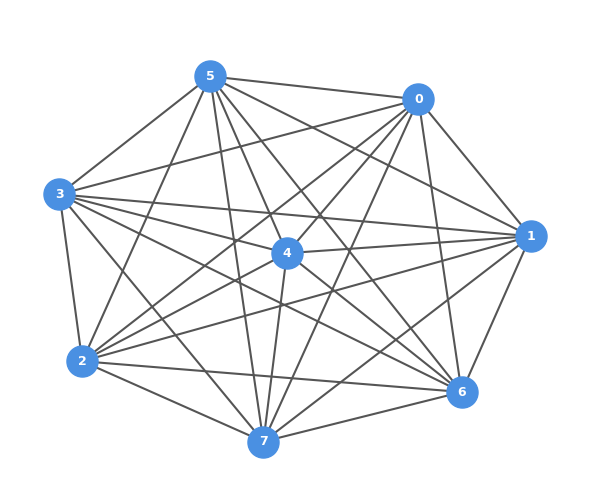

In [ ]:
# Comando NetworkX
# nx.complete_graph(n)

_g = nx.complete_graph(8)
print(f"Nodos: {_g.number_of_nodes()}, Aristas: {_g.number_of_edges()}")
print(f"Grado de cada nodo: {[d for _, d in _g.degree()]}")
show(_g, "Grafo Completo K8")

---
## Grafo Bipartito Completo — `complete_bipartite_graph(n1, n2)`

**Dos conjuntos de nodos donde cada nodo de un grupo conecta con todos los del otro.**

| Propiedad | Valor |
|-----------|-------|
| Nodos | n1 + n2 |
| Aristas | n1 × n2 |
| Ciclos | Solo pares |
| Conexo | ✅ Siempre |

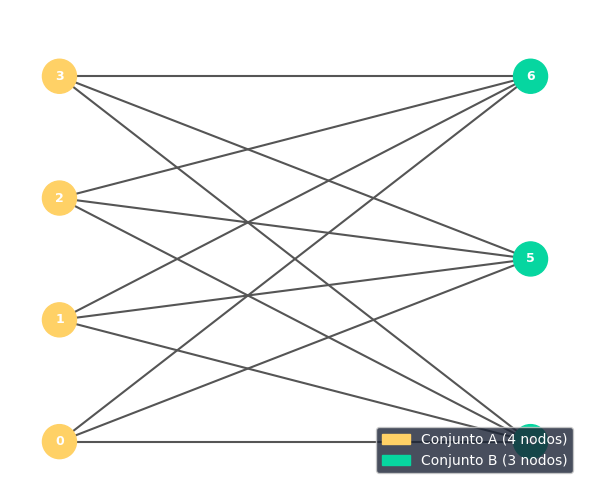

In [ ]:
# Comando NetworkX
# nx.complete_bipartite_graph(n1, n2)

_g = nx.complete_bipartite_graph(4, 3)
pos = nx.bipartite_layout(_g, nodes=range(4))
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("#0f1419")
ax.set_facecolor("#0f1419")
colors = ["#ffd166" if n < 4 else "#06d6a0" for n in _g.nodes()]
nx.draw(
    _g,
    pos=pos,
    ax=ax,
    node_color=colors,
    node_size=600,
    edge_color="#555555",
    width=1.5,
    with_labels=True,
    font_color="white",
    font_size=9,
    font_weight="bold",
)
ax.set_title("Grafo Bipartito Completo K(4,3)", color="white", fontsize=12, pad=10)
p1 = mpatches.Patch(color="#ffd166", label="Conjunto A (4 nodos)")
p2 = mpatches.Patch(color="#06d6a0", label="Conjunto B (3 nodos)")
ax.legend(handles=[p1, p2], facecolor="#1a2234", labelcolor="white", loc="lower right")
plt.tight_layout()
plt.show()

---
## Grafo Camino (Path) — `path_graph(n)`

**Nodos conectados en una cadena lineal, el más simple de todos.**

| Propiedad | Valor |
|-----------|-------|
| Nodos | n |
| Aristas | n-1 |
| Grado extremos | 1 |
| Grado interior | 2 |
| Diámetro | n-1 |

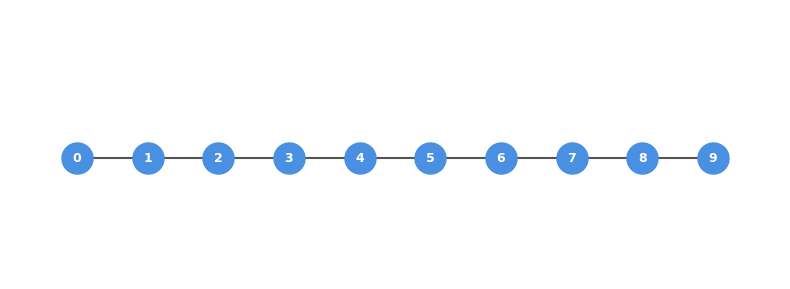

In [ ]:
# Comando NetworkX
# nx.path_graph(n)

_g = nx.path_graph(10)
pos = {i: (i, 0) for i in _g.nodes()}
fig, ax = plt.subplots(figsize=(8, 3))
fig.patch.set_facecolor("#0f1419")
ax.set_facecolor("#0f1419")
nx.draw(_g, pos=pos, ax=ax, **STYLE)
ax.set_title("Grafo Camino P10", color="white", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

---
## Grafo Ciclo (Cycle) — `cycle_graph(n)`

**Todos los nodos forman un anillo cerrado. Cada nodo tiene grado 2.**

| Propiedad | Valor |
|-----------|-------|
| Nodos | n |
| Aristas | n |
| Grado | 2 (uniforme) |
| Diámetro | ⌊n/2⌋ |
| Hamiltoniano | ✅ |

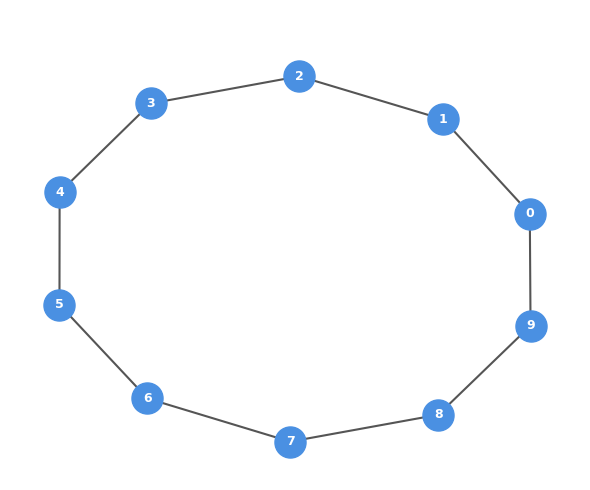

In [ ]:
# Comando NetworkX
# nx.cycle_graph(n)

_g = nx.cycle_graph(10)
show(_g, "Grafo Ciclo C10")

---
## Grafo Estrella (Star) — `star_graph(n)`

**Un nodo central conectado a todos los demás. Topología hub-and-spoke.**

| Propiedad | Valor |
|-----------|-------|
| Nodos | n+1 |
| Aristas | n |
| Grado centro | n |
| Grado hojas | 1 |
| Diámetro | 2 |

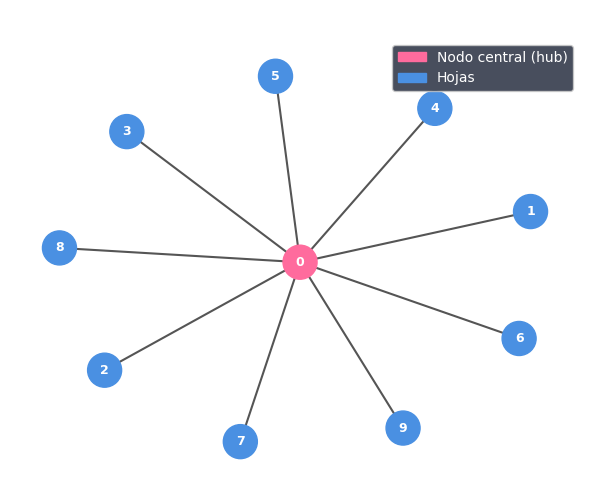

In [ ]:
# Comando NetworkX
# nx.star_graph(n)

_g = nx.star_graph(9)
colors = ["#ff6b9d" if n == 0 else "#4a90e2" for n in _g.nodes()]
pos = nx.spring_layout(_g, seed=42)
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("#0f1419")
ax.set_facecolor("#0f1419")
nx.draw(
    _g,
    pos=pos,
    ax=ax,
    node_color=colors,
    node_size=600,
    edge_color="#555555",
    width=1.5,
    with_labels=True,
    font_color="white",
    font_size=9,
    font_weight="bold",
)
ax.set_title("Grafo Estrella S9", color="white", fontsize=12, pad=10)
p1 = mpatches.Patch(color="#ff6b9d", label="Nodo central (hub)")
p2 = mpatches.Patch(color="#4a90e2", label="Hojas")
ax.legend(handles=[p1, p2], facecolor="#1a2234", labelcolor="white")
plt.tight_layout()
plt.show()

---
## Grafo Rueda (Wheel) — `wheel_graph(n)`

**Un ciclo exterior con un hub central conectado a todos los nodos del ciclo.**

| Propiedad | Valor |
|-----------|-------|
| Nodos | n |
| Aristas | 2(n-1) |
| Grado hub | n-1 |
| Grado rueda | 3 |
| Planar | ✅ |

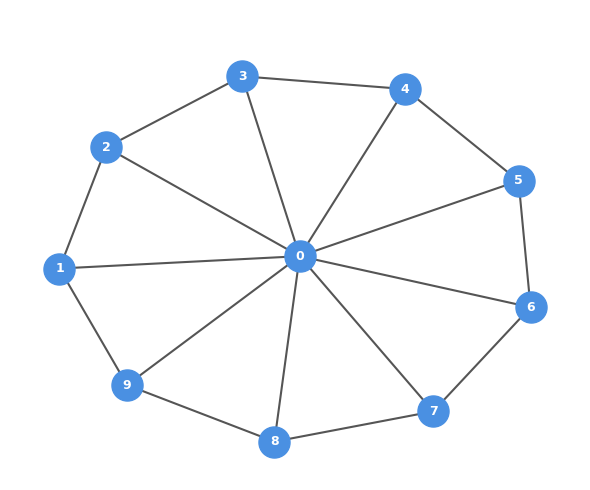

In [ ]:
# Comando NetworkX
# nx.wheel_graph(n)

_g = nx.wheel_graph(10)
colors = ["#ff6b9d" if n == 0 else "#4a90e2" for n in _g.nodes()]
show(_g, "Grafo Rueda W10")

---
# 2️⃣ Árboles

---
## Árbol Aleatorio — `random_tree(n)`

**Grafo conexo sin ciclos con n nodos. Los árboles tienen exactamente n-1 aristas.**

| Propiedad | Valor |
|-----------|-------|
| Nodos | n |
| Aristas | n-1 |
| Ciclos | 0 (acíclico) |
| Conexo | ✅ |
| Diámetro | Variable |

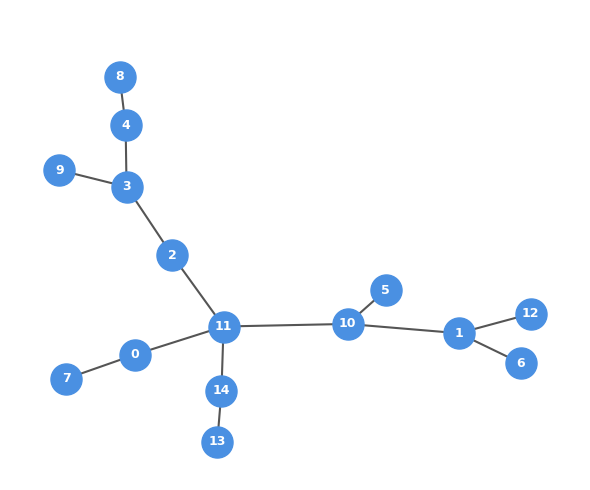

In [ ]:
# Comando NetworkX
# nx.random_labeled_tree(n, seed=42)

_g = nx.random_labeled_tree(15, seed=42)
show(_g, "Árbol Aleatorio (15 nodos)")

---
## Árbol Balanceado — `balanced_tree(r, h)`

**Árbol r-ario de altura h. Cada nodo interno tiene exactamente r hijos.**

| Propiedad | Valor |
|-----------|-------|
| Branching (r) | r hijos por nodo |
| Altura (h) | h niveles |
| Nodos | (r^(h+1)-1)/(r-1) |
| Aristas | nodos - 1 |

Nodos: 40, Aristas: 39


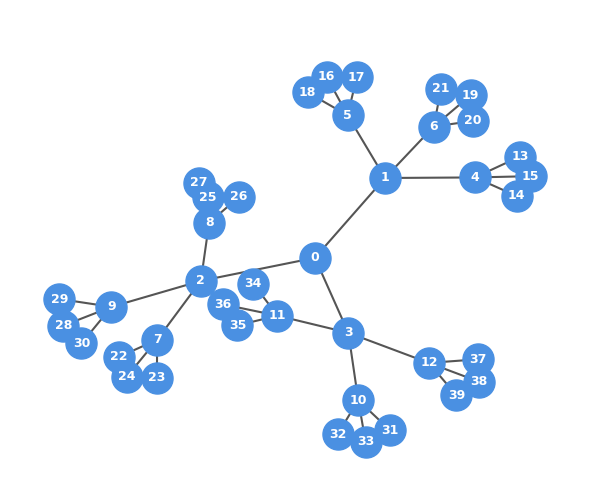

In [ ]:
# Comando NetworkX
# nx.balanced_tree(r=3, h=3)

_g = nx.balanced_tree(r=3, h=3)
pos = (
    nx.nx_agraph.graphviz_layout(_g, prog="dot")
    if False
    else nx.spring_layout(_g, seed=1)
)
print(f"Nodos: {_g.number_of_nodes()}, Aristas: {_g.number_of_edges()}")
show(_g, "Árbol Balanceado (r=3, h=3)")

---
## Árbol de Prefijos / Grafo Bintree — `full_rary_tree(r, n)`

**Árbol r-ario completo con exactamente n nodos.**

| Propiedad | Valor |
|-----------|-------|
| Hijos por nodo | r (máximo) |
| Nodos | n (exacto) |
| Acíclico | ✅ |
| Conexo | ✅ |

Árbol binario: 15 nodos, 14 aristas


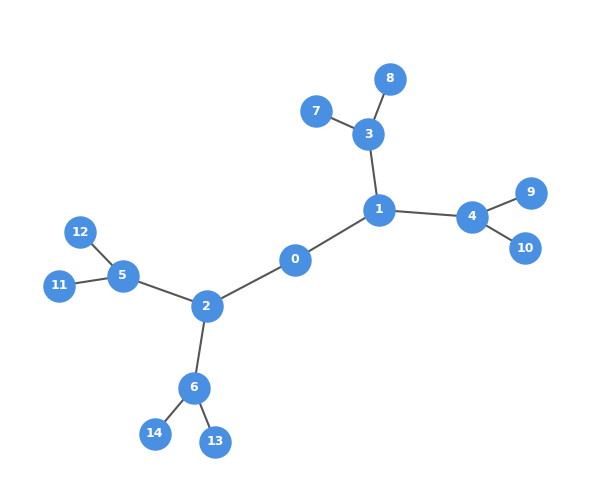

In [ ]:
# Comando NetworkX
# nx.full_rary_tree(r=2, n=15)

_g = nx.full_rary_tree(r=2, n=15)
print(f"Árbol binario: {_g.number_of_nodes()} nodos, {_g.number_of_edges()} aristas")
show(_g, "Árbol r-ario Completo (binario, n=15)")

---
# 3️⃣ Cuadrículas y Lattices

---
## Cuadrícula 2D — `grid_2d_graph(m, n)`

**Nodos dispuestos en una malla rectangular m×n. Modela redes de imagen o mapas.**

| Propiedad | Valor |
|-----------|-------|
| Nodos | m × n |
| Grado interior | 4 |
| Grado esquinas | 2 |
| Grado bordes | 3 |
| Planar | ✅ |

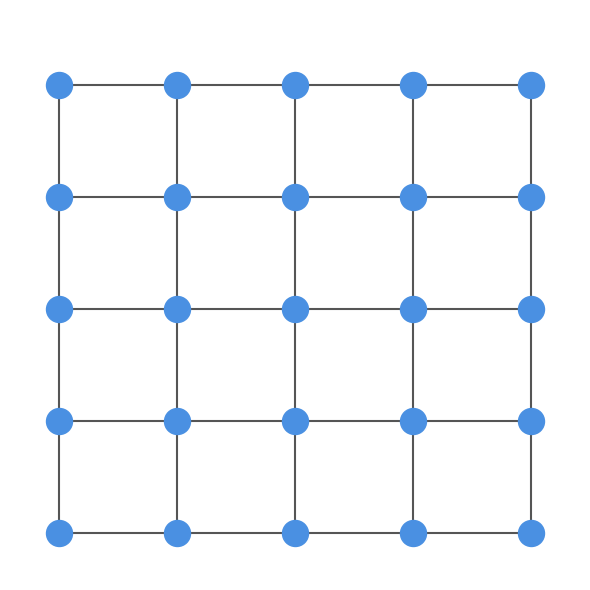

In [ ]:
# Comando NetworkX
# nx.grid_2d_graph(5, 5)

_g = nx.grid_2d_graph(5, 5)
pos = {(x, y): (x, y) for x, y in _g.nodes()}
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor("#0f1419")
ax.set_facecolor("#0f1419")
nx.draw(
    _g,
    pos=pos,
    ax=ax,
    node_color="#4a90e2",
    node_size=350,
    edge_color="#555",
    width=1.5,
    with_labels=False,
)
ax.set_title("Cuadrícula 2D (5×5)", color="white", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

---
## Cuadrícula Hexagonal — `hexagonal_lattice_graph(m, n)`

**Lattice hexagonal. Aparece en cristalografía, grafeno y juegos de estrategia.**

| Propiedad | Valor |
|-----------|-------|
| Grado interior | 3 |
| Geometría | Hexagonal |
| Planar | ✅ |
| Aplicaciones | Física, juegos |

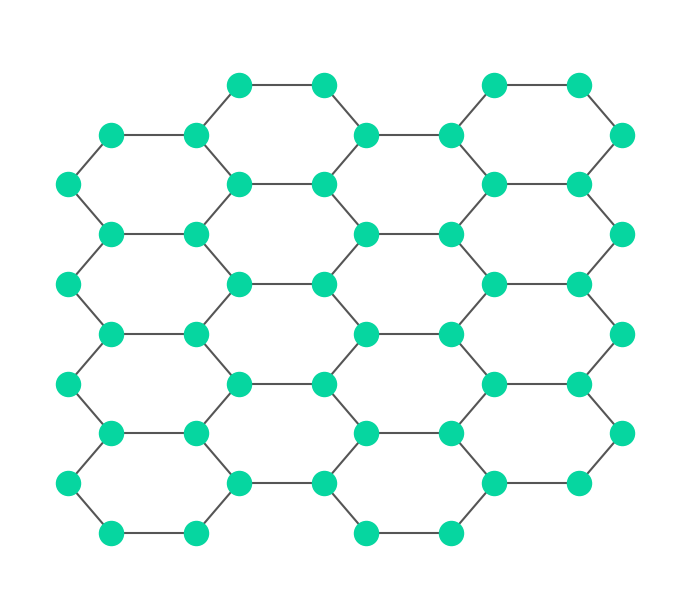

In [ ]:
# Comando NetworkX
# nx.hexagonal_lattice_graph(4, 4)

_g = nx.hexagonal_lattice_graph(4, 4)
pos = nx.get_node_attributes(_g, "pos")
if not pos:
    pos = nx.spring_layout(_g, seed=42)
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#0f1419")
ax.set_facecolor("#0f1419")
nx.draw(
    _g,
    pos=pos,
    ax=ax,
    node_color="#06d6a0",
    node_size=300,
    edge_color="#555",
    width=1.5,
    with_labels=False,
)
ax.set_title("Lattice Hexagonal (4×4)", color="white", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

---
## Cuadrícula Triangular — `triangular_lattice_graph(m, n)`

**Lattice triangular donde cada nodo interior tiene grado 6.**

| Propiedad | Valor |
|-----------|-------|
| Grado interior | 6 |
| Geometría | Triangular |
| Planar | ✅ |
| Usos | Física estadística |

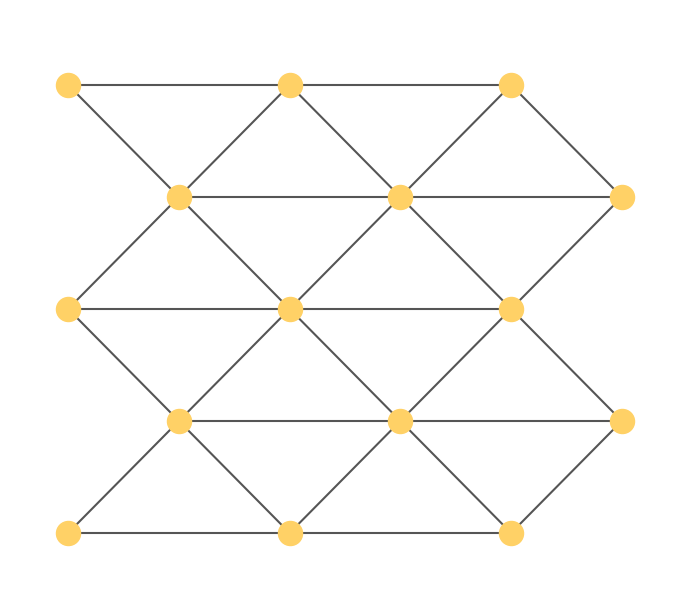

In [ ]:
# Comando NetworkX
# nx.triangular_lattice_graph(4, 4)

_g = nx.triangular_lattice_graph(4, 4)
pos = nx.get_node_attributes(_g, "pos")
if not pos:
    pos = nx.spring_layout(_g, seed=42)
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#0f1419")
ax.set_facecolor("#0f1419")
nx.draw(
    _g,
    pos=pos,
    ax=ax,
    node_color="#ffd166",
    node_size=300,
    edge_color="#555",
    width=1.5,
    with_labels=False,
)
ax.set_title("Lattice Triangular (4×4)", color="white", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

---
# 4️⃣ Grafos Aleatorios

---
## Erdős–Rényi G(n,p) — `erdos_renyi_graph(n, p)`

**Cada par de nodos se conecta con probabilidad p. El modelo aleatorio clásico.**

| Propiedad | Valor |
|-----------|-------|
| Esperanza aristas | p·n(n-1)/2 |
| Umbral conexión | p ≈ ln(n)/n |
| Grado esperado | p(n-1) |
| Modelo | Binomial |

Nodos: 20, Aristas: 37
Conexo: False


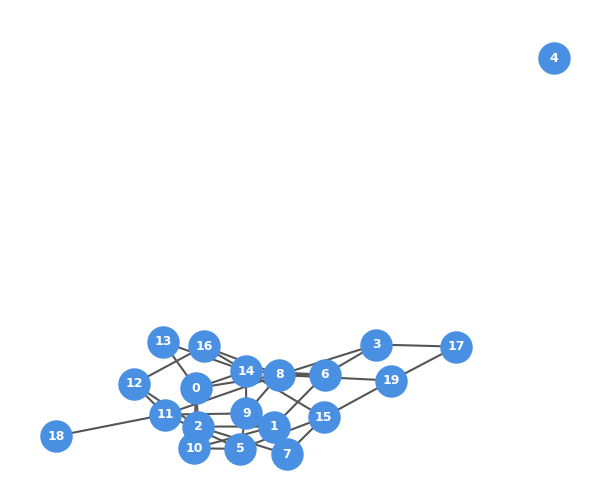

In [ ]:
# Comando NetworkX
# nx.erdos_renyi_graph(n=20, p=0.2, seed=42)

_g = nx.erdos_renyi_graph(n=20, p=0.2, seed=42)
print(f"Nodos: {_g.number_of_nodes()}, Aristas: {_g.number_of_edges()}")
print(f"Conexo: {nx.is_connected(_g)}")
show(_g, "Erdős–Rényi G(20, p=0.2)")

---
## Barabási–Albert (Scale-Free) — `barabasi_albert_graph(n, m)`

**Crecimiento preferencial: los nodos más conectados atraen más aristas. Genera hubs. Modela internet, redes sociales.**

| Propiedad | Valor |
|-----------|-------|
| Distribución grado | Ley de potencia P(k) ~ k^-3 |
| Hubs | ✅ Aparecen naturalmente |
| Diámetro | Pequeño |
| Aplicaciones | Redes sociales, WWW |

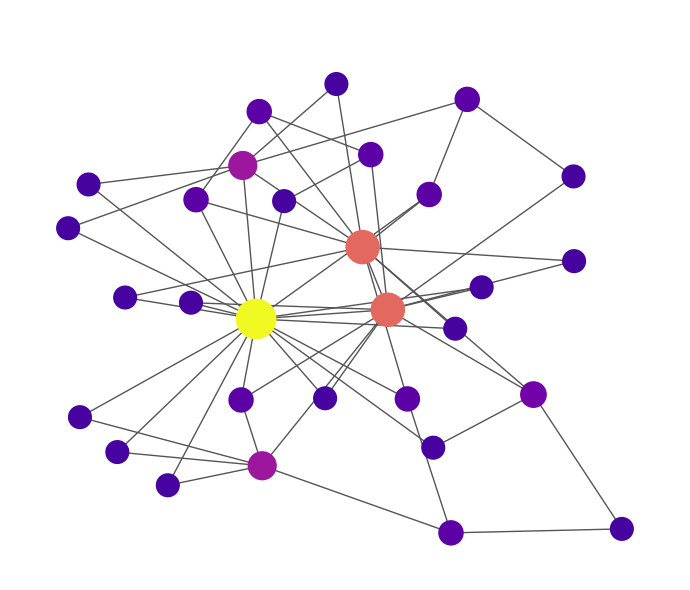

In [ ]:
# Comando NetworkX
# nx.barabasi_albert_graph(n=30, m=2, seed=42)

_g = nx.barabasi_albert_graph(n=30, m=2, seed=42)
degrees = dict(_g.degree())
max_deg = max(degrees.values())
colors = [plt.cm.plasma(degrees[n] / max_deg) for n in _g.nodes()]
sizes = [200 + 600 * degrees[n] / max_deg for n in _g.nodes()]
pos = nx.spring_layout(_g, seed=42)
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#0f1419")
ax.set_facecolor("#0f1419")
nx.draw(
    _g,
    pos=pos,
    ax=ax,
    node_color=colors,
    node_size=sizes,
    edge_color="#555",
    width=1.0,
    with_labels=False,
)
ax.set_title(
    "Barabási–Albert (n=30, m=2) — nodos más grandes = más conexiones",
    color="white",
    fontsize=11,
    pad=10,
)
plt.tight_layout()
plt.show()

---
## Watts–Strogatz (Pequeño Mundo) — `watts_strogatz_graph(n, k, p)`

**Parte de un anillo regular y rewire aleatoriamente. Combina alta clusterización y diámetro corto (fenómeno small-world).**

| Propiedad | Valor |
|-----------|-------|
| Clusterización | Alta |
| Diámetro | Pequeño (log n) |
| Parámetro p | 0=regular, 1=aleatorio |
| Aplicaciones | Redes neuronales, sociales |

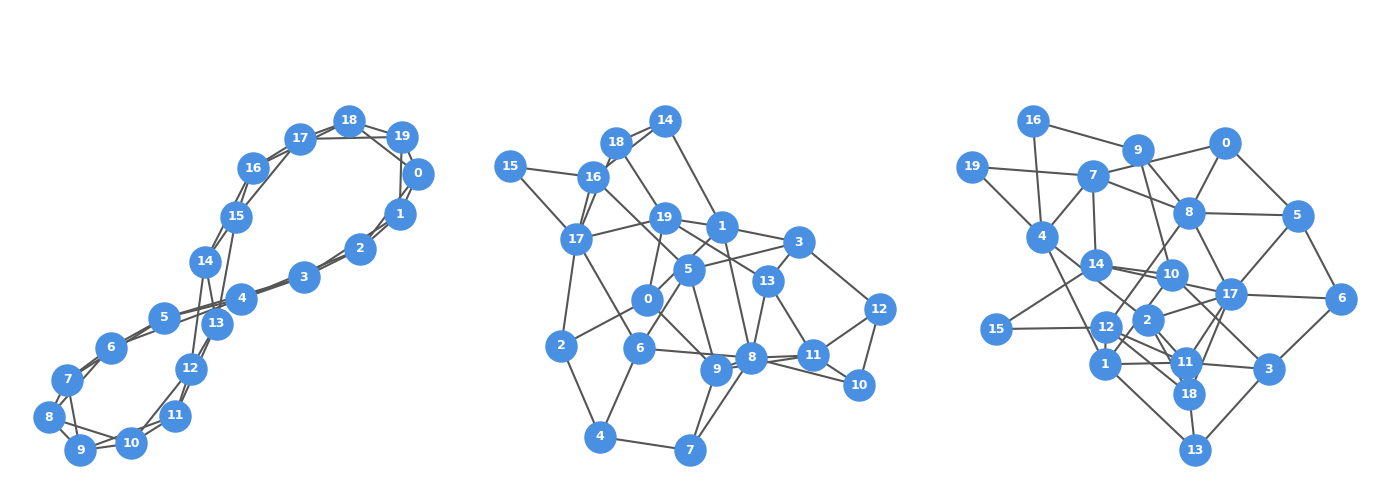

In [ ]:
# Comando NetworkX
# nx.watts_strogatz_graph(n=20, k=4, p=0.3, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor("#0f1419")
for ax, p, label in zip(
    axes,
    [0.0, 0.3, 1.0],
    ["p=0 (regular)", "p=0.3 (small-world)", "p=1.0 (aleatorio)"],
    strict=False,
):
    _g = nx.watts_strogatz_graph(n=20, k=4, p=p, seed=42)
    ax.set_facecolor("#0f1419")
    nx.draw(_g, ax=ax, **STYLE)
    ax.set_title(f"Watts–Strogatz\n{label}", color="white", fontsize=11)
plt.suptitle("Evolución del modelo Watts–Strogatz según p", color="white", fontsize=13)
plt.tight_layout()
plt.show()

---
## Random Regular Graph — `random_regular_graph(d, n)`

**Todos los nodos tienen exactamente el mismo grado d. Útil como baseline en estudios de redes.**

| Propiedad | Valor |
|-----------|-------|
| Grado | d (uniforme) |
| Nodos | n |
| Restricción | d·n debe ser par |
| Distribución | Uniforme |

Grados: {3}


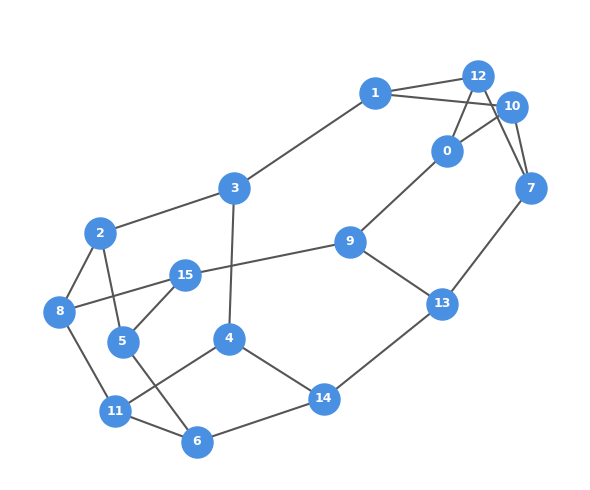

In [ ]:
# Comando NetworkX
# nx.random_regular_graph(d=3, n=16, seed=42)

_g = nx.random_regular_graph(d=3, n=16, seed=42)
print(f"Grados: {set(dict(_g.degree()).values())}")  # todos iguales
show(_g, "Grafo Regular (d=3, n=16)")

---
## Stochastic Block Model — `stochastic_block_model(sizes, p)`

**Nodos divididos en comunidades. Aristas dentro de cada bloque con prob p_in y entre bloques con p_out. Modela redes con estructura de comunidades.**

| Propiedad | Valor |
|-----------|-------|
| Bloques | k grupos |
| p_in | Densidad intragrupo |
| p_out | Densidad intergrupo |
| Usos | Detección de comunidades |

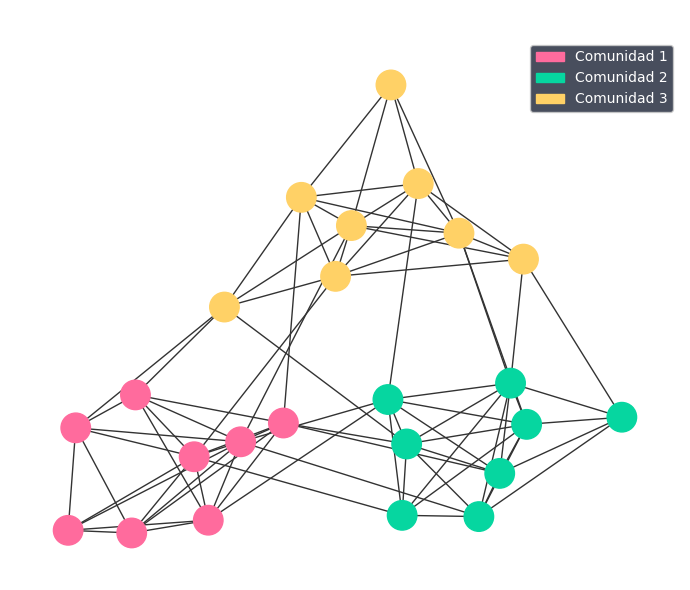

In [ ]:
# Comando NetworkX
# nx.stochastic_block_model(sizes, p, seed=42)

sizes = [8, 8, 8]
p = [[0.7, 0.05, 0.05], [0.05, 0.7, 0.05], [0.05, 0.05, 0.7]]
_g = nx.stochastic_block_model(sizes, p, seed=42)
colors_map = ["#ff6b9d"] * 8 + ["#06d6a0"] * 8 + ["#ffd166"] * 8
pos = nx.spring_layout(_g, seed=42)
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#0f1419")
ax.set_facecolor("#0f1419")
nx.draw(
    _g,
    pos=pos,
    ax=ax,
    node_color=colors_map,
    node_size=450,
    edge_color="#333",
    width=1.0,
    with_labels=False,
)
ax.set_title(
    "Stochastic Block Model (3 comunidades)", color="white", fontsize=12, pad=10
)
patches = [
    mpatches.Patch(color=c, label=f"Comunidad {i + 1}")
    for i, c in enumerate(["#ff6b9d", "#06d6a0", "#ffd166"])
]
ax.legend(handles=patches, facecolor="#1a2234", labelcolor="white")
plt.tight_layout()
plt.show()

---
# 5️⃣ Grafos Famosos (Named Graphs)

Estos grafos tienen nombre propio porque aparecen en teoría de grafos, matemáticas
o informática con propiedades únicas y relevantes.

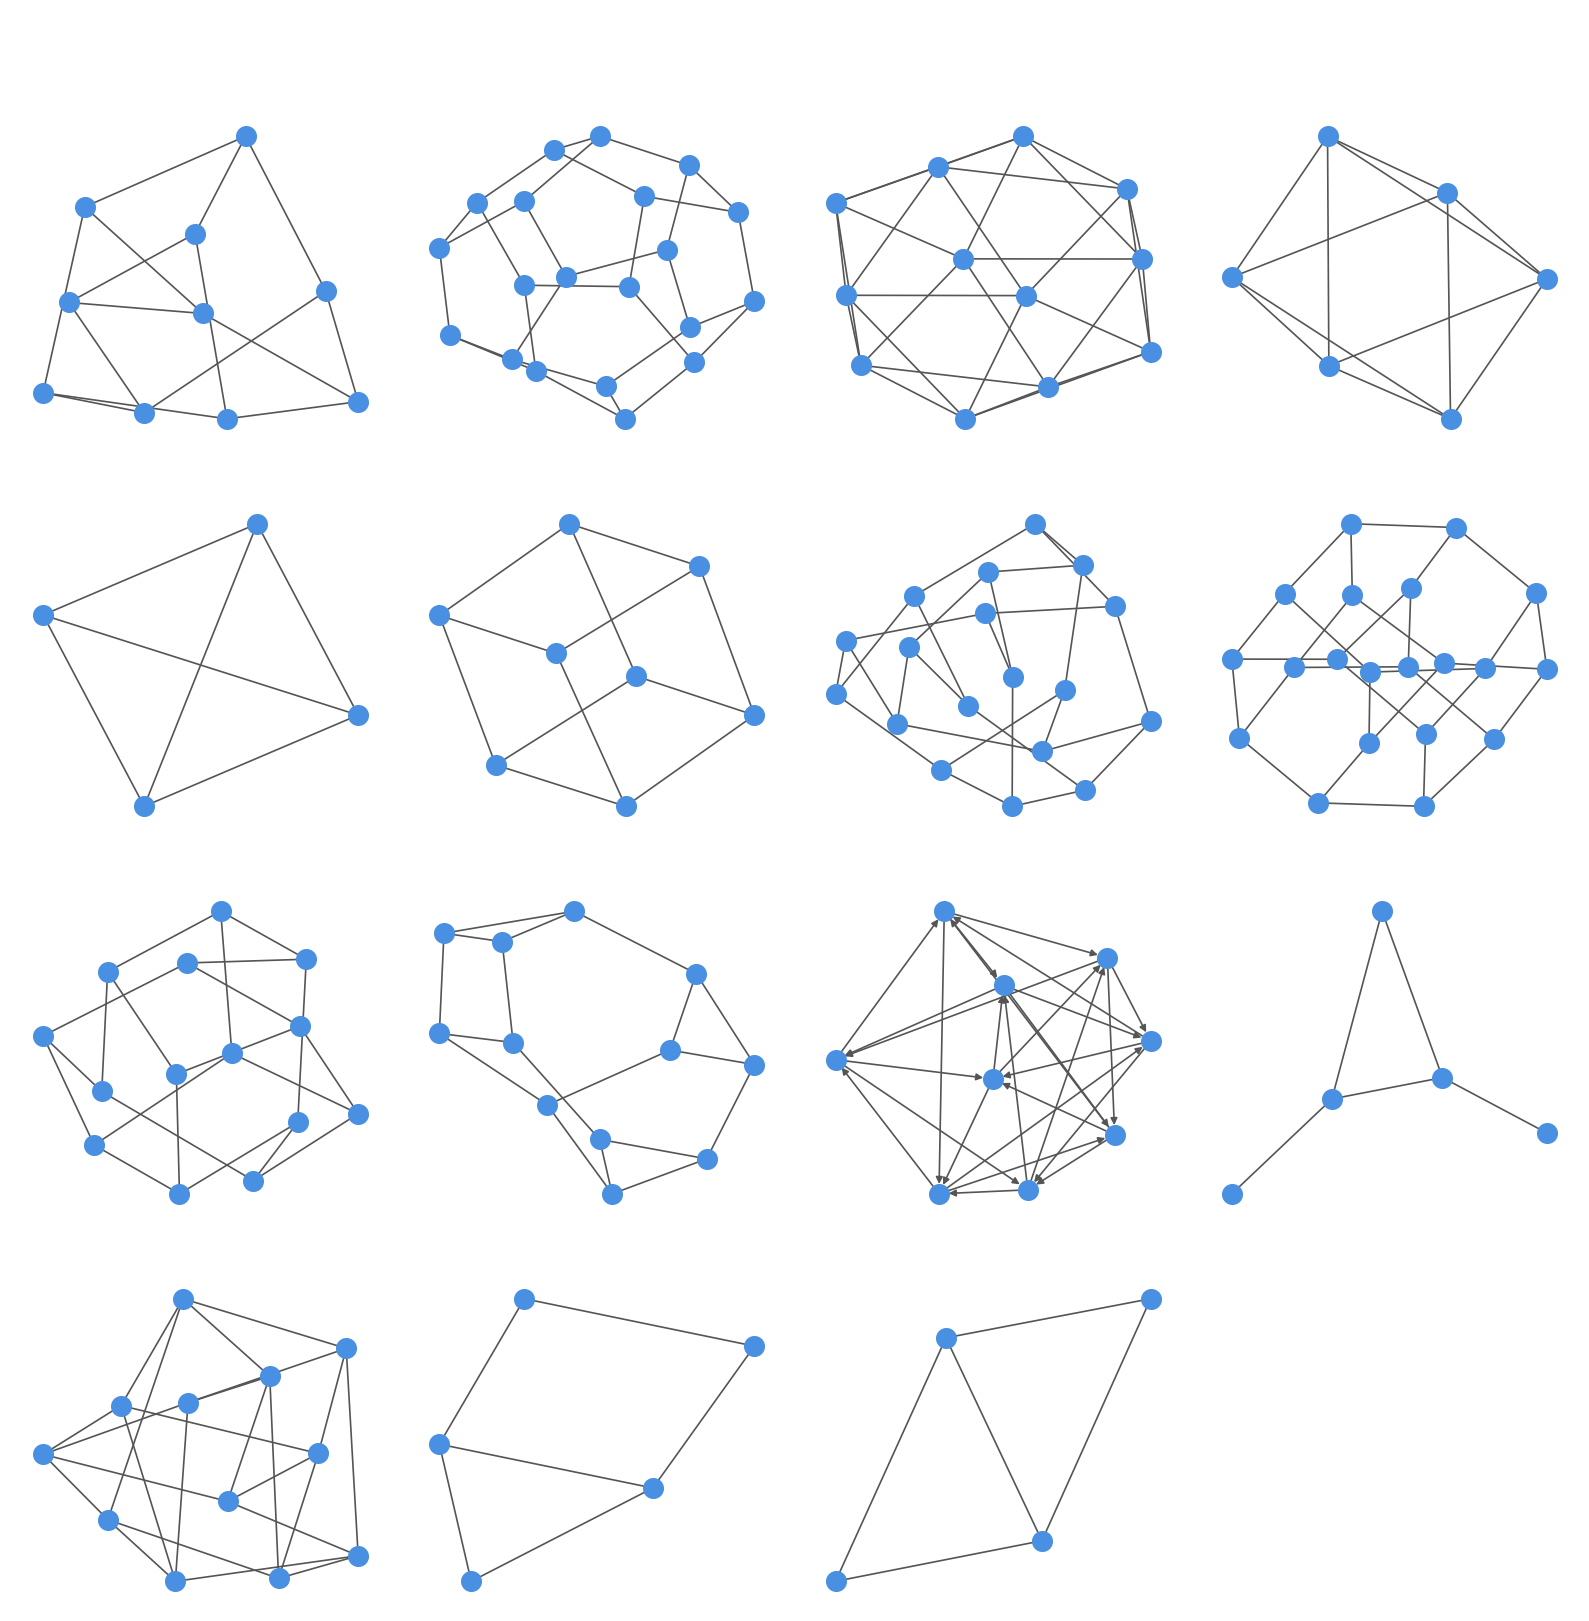

  Petersen         — 10 nodos, 3-regular, no planar. Benchmark clásico.
  Dodecahedro      — 20 nodos, 3-regular, planar, hamiltoniano.
  Icosaedro        — 12 nodos, 5-regular. Sólido platónico.
  Octaedro         — 6 nodos, 4-regular. Sólido platónico.
  Tetraedro        — 4 nodos, 3-regular. K4, sólido platónico.
  Cubo             — 8 nodos, 3-regular, planar. Hipercubo Q3.
  Pappus           — 18 nodos, 3-regular, bipartito.
  Desargues        — 20 nodos, 3-regular, no planar.
  Heawood          — 14 nodos, 3-regular, bipartito.
  Moser Spindle    — 12 nodos, 3-regular, no hamiltoniano.
  Paley 9          — 9 nodos, self-complementario.
  Bull             — 5 nodos, triangulo con dos colas.
  Chvatal          — 12 nodos, 4-regular, vertex-transitive.
  House            — 5 nodos, forma de casa.
  Diamond          — 4 nodos, K4 sin una arista.


In [ ]:
named = {
    "Petersen": (
        nx.petersen_graph(),
        "10 nodos, 3-regular, no planar. Benchmark clásico.",
    ),
    "Dodecahedro": (
        nx.dodecahedral_graph(),
        "20 nodos, 3-regular, planar, hamiltoniano.",
    ),
    "Icosaedro": (nx.icosahedral_graph(), "12 nodos, 5-regular. Sólido platónico."),
    "Octaedro": (nx.octahedral_graph(), "6 nodos, 4-regular. Sólido platónico."),
    "Tetraedro": (nx.tetrahedral_graph(), "4 nodos, 3-regular. K4, sólido platónico."),
    "Cubo": (nx.cubical_graph(), "8 nodos, 3-regular, planar. Hipercubo Q3."),
    "Pappus": (nx.pappus_graph(), "18 nodos, 3-regular, bipartito."),
    "Desargues": (nx.desargues_graph(), "20 nodos, 3-regular, no planar."),
    "Heawood": (nx.heawood_graph(), "14 nodos, 3-regular, bipartito."),
    "Moser Spindle": (nx.frucht_graph(), "12 nodos, 3-regular, no hamiltoniano."),
    "Paley 9": (nx.paley_graph(9), "9 nodos, self-complementario."),
    "Bull": (nx.bull_graph(), "5 nodos, triangulo con dos colas."),
    "Chvatal": (nx.chvatal_graph(), "12 nodos, 4-regular, vertex-transitive."),
    "House": (nx.house_graph(), "5 nodos, forma de casa."),
    "Diamond": (nx.diamond_graph(), "4 nodos, K4 sin una arista."),
}

cols = 4
rows = -(-len(named) // cols)  # ceil division
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
fig.patch.set_facecolor("#0f1419")
axes = axes.flatten()

for ax, (name, (_g, _desc)) in zip(axes, named.items(), strict=False):
    ax.set_facecolor("#0f1419")
    try:
        pos = nx.spring_layout(_g, seed=42)
    except Exception:
        pos = nx.random_layout(_g)
    nx.draw(
        _g,
        pos=pos,
        ax=ax,
        node_color="#4a90e2",
        node_size=200,
        edge_color="#555",
        width=1.2,
        with_labels=False,
    )
    ax.set_title(
        f"{name}\n{_g.number_of_nodes()}n · {_g.number_of_edges()}e",
        color="white",
        fontsize=9,
        pad=4,
    )

for ax in axes[len(named) :]:
    ax.set_visible(False)

plt.suptitle(
    "Grafos con Nombre Propio (Named Graphs)", color="white", fontsize=15, y=1.01
)
plt.tight_layout()
plt.show()

for name, (_g, _desc) in named.items():
    print(f"  {name:16s} — {_desc}")

---
# 6️⃣ Grafos Dirigidos (DiGraphs)

---
## DAG Aleatorio — `gnm_random_graph (DiGraph)`

**Grafo Acíclico Dirigido (Directed Acyclic Graph). Las aristas tienen dirección y no forman ciclos. Modela dependencias, pipelines.**

| Propiedad | Valor |
|-----------|-------|
| Aristas | Dirigidas |
| Ciclos | 0 (acíclico) |
| Usos | Dependencias, flujos |
| Orden topológico | ✅ Siempre existe |

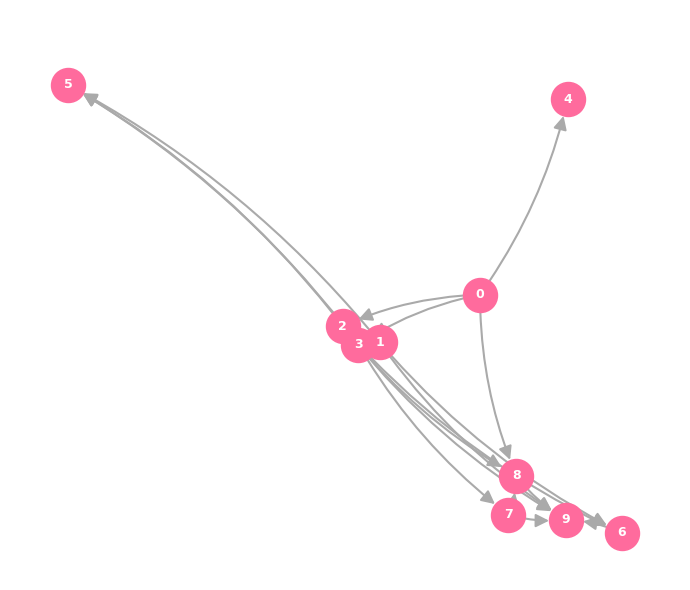

Es acíclico: True


In [ ]:
# Comando NetworkX
# nx.gnm_random_graph(n, m, directed=True)

import random

random.seed(42)
n = 10
_g = nx.DiGraph()
_g.add_nodes_from(range(n))
# Crear DAG: solo añadir aristas de nodo menor a mayor (garantiza acíclico)
for i in range(n):
    for j in range(i + 1, n):
        if random.random() < 0.35:
            _g.add_edge(i, j)
pos = nx.spring_layout(_g, seed=42)
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#0f1419")
ax.set_facecolor("#0f1419")
nx.draw(
    _g,
    pos=pos,
    ax=ax,
    node_color="#ff6b9d",
    node_size=600,
    edge_color="#aaa",
    width=1.5,
    with_labels=True,
    font_color="white",
    font_size=9,
    font_weight="bold",
    arrows=True,
    arrowsize=20,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.1",
)
ax.set_title(f"DAG Aleatorio ({n} nodos)", color="white", fontsize=12, pad=10)
plt.tight_layout()
plt.show()
print(f"Es acíclico: {nx.is_directed_acyclic_graph(_g)}")

---
## Grafo Completo Dirigido (Tournament) — `tournament.random_tournament(n)`

**Entre cada par de nodos hay exactamente una arista dirigida. Modela competiciones round-robin.**

| Propiedad | Valor |
|-----------|-------|
| Aristas | n(n-1)/2 (dirigidas) |
| Grado entrada | Variable |
| Grado salida | Variable |
| Hamiltoniano | ✅ Siempre |

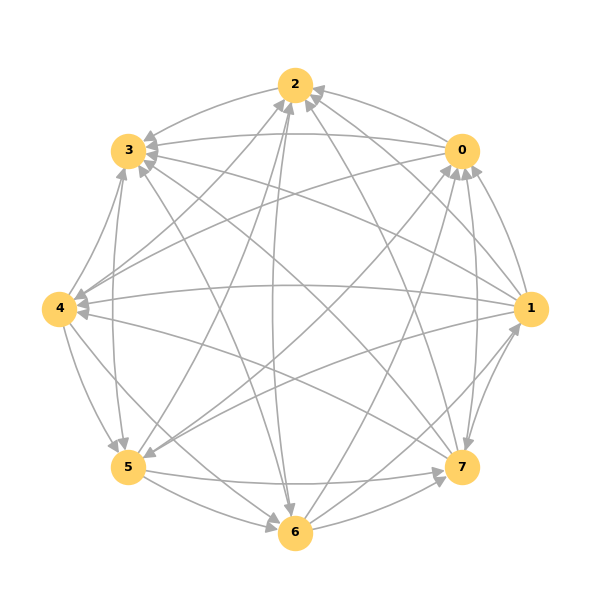

In [ ]:
# Comando NetworkX
# nx.tournament.random_tournament(n, seed=42)

_g = nx.tournament.random_tournament(8, seed=42)
pos = nx.circular_layout(_g)
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor("#0f1419")
ax.set_facecolor("#0f1419")
nx.draw(
    _g,
    pos=pos,
    ax=ax,
    node_color="#ffd166",
    node_size=600,
    edge_color="#aaa",
    width=1.2,
    with_labels=True,
    font_color="black",
    font_size=9,
    font_weight="bold",
    arrows=True,
    arrowsize=18,
    connectionstyle="arc3,rad=0.1",
)
ax.set_title("Tournament (Round-Robin, n=8)", color="white", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

---
# 7️⃣ Grafos Especiales y Avanzados

---
## Hypercubo Q_n — `hypercube_graph(n)`

**n-dimensional hypercube: los nodos son cadenas binarias de longitud n, conectadas si difieren en 1 bit.**

| Propiedad | Valor |
|-----------|-------|
| Nodos | 2^n |
| Aristas | n·2^(n-1) |
| Grado | n (uniforme) |
| Diámetro | n |
| Bipartito | ✅ |

Q4: 16 nodos, 32 aristas, grado=4


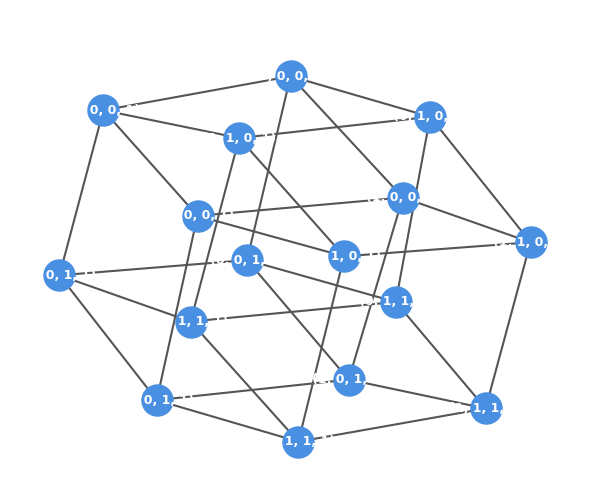

In [ ]:
# Comando NetworkX
# nx.hypercube_graph(4)

_g = nx.hypercube_graph(4)
print(f"Q4: {_g.number_of_nodes()} nodos, {_g.number_of_edges()} aristas, grado={4}")
show(_g, "Hipercubo Q4 (16 nodos)")

---
## Grafo de Kneser — `kneser_graph(n, k)`

**Nodos son subconjuntos de tamaño k de {1..n}; aristas entre subconjuntos disjuntos. Número cromático = n-2k+2.**

| Propiedad | Valor |
|-----------|-------|
| Nodos | C(n,k) |
| Conexo | Si n ≥ 2k+1 |
| Número cromático | n - 2k + 2 |
| Clásico | Petersen = Kneser(5,2) |

Kneser(5,2) = Petersen: 10 nodos, 15 aristas


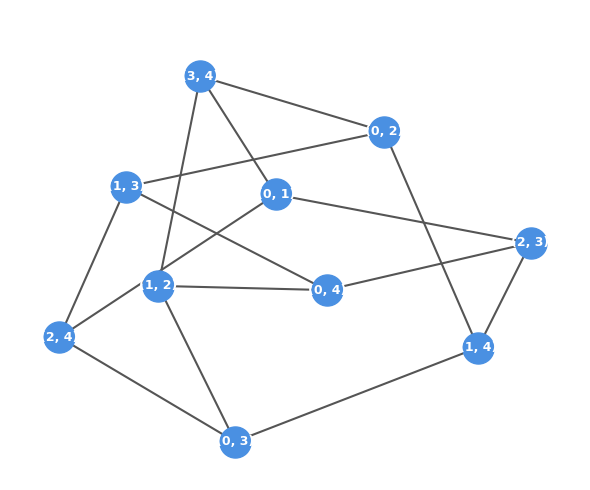

In [ ]:
# Comando NetworkX
# nx.kneser_graph(5, 2)

_g = nx.kneser_graph(5, 2)  # Este ES el grafo de Petersen
print(
    f"Kneser(5,2) = Petersen: {_g.number_of_nodes()} nodos, {_g.number_of_edges()} aristas"
)
show(_g, "Grafo de Kneser (5, 2) = Petersen")

---
## Circulant Graph — `circulant_graph(n, offsets)`

**Cada nodo i conecta con i±offset (mod n). Generaliza ciclos y grafos completos.**

| Propiedad | Valor |
|-----------|-------|
| Nodos | n |
| Grado | 2 × |offsets| |
| Vértice-transitivo | ✅ |
| Regular | ✅ |

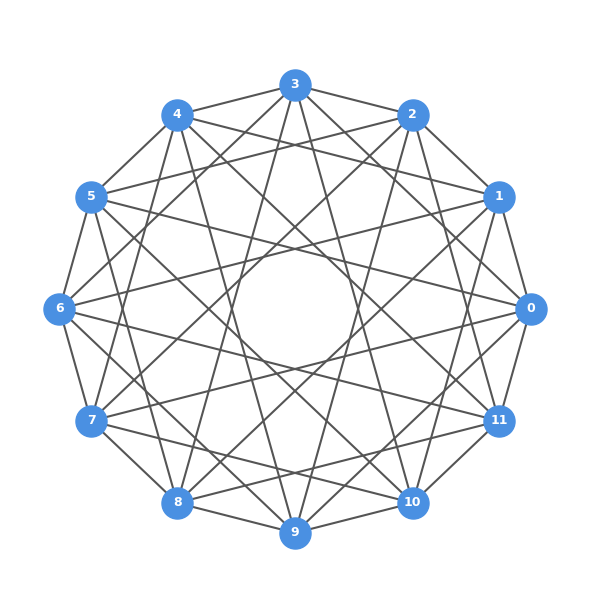

In [ ]:
# Comando NetworkX
# nx.circulant_graph(12, [1, 3, 5])

_g = nx.circulant_graph(12, [1, 3, 5])
pos = nx.circular_layout(_g)
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor("#0f1419")
ax.set_facecolor("#0f1419")
nx.draw(
    _g,
    pos=pos,
    ax=ax,
    node_color="#4a90e2",
    node_size=500,
    edge_color="#555",
    width=1.5,
    with_labels=True,
    font_color="white",
    font_size=9,
    font_weight="bold",
)
ax.set_title("Circulant Graph C(12; 1,3,5)", color="white", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

---
## Line Graph — `line_graph(G)`

**El line graph de G tiene una arista por cada arista de G original; dos nodos del line graph se conectan si las aristas originales comparten un extremo.**

| Propiedad | Valor |
|-----------|-------|
| Nodos | = aristas de G |
| Aristas | Variable |
| Usos | Coloreo de aristas |
| Propiedad | Transforma aristas en nodos |

Petersen: 10 nodos, 15 aristas
Line graph: 15 nodos, 30 aristas


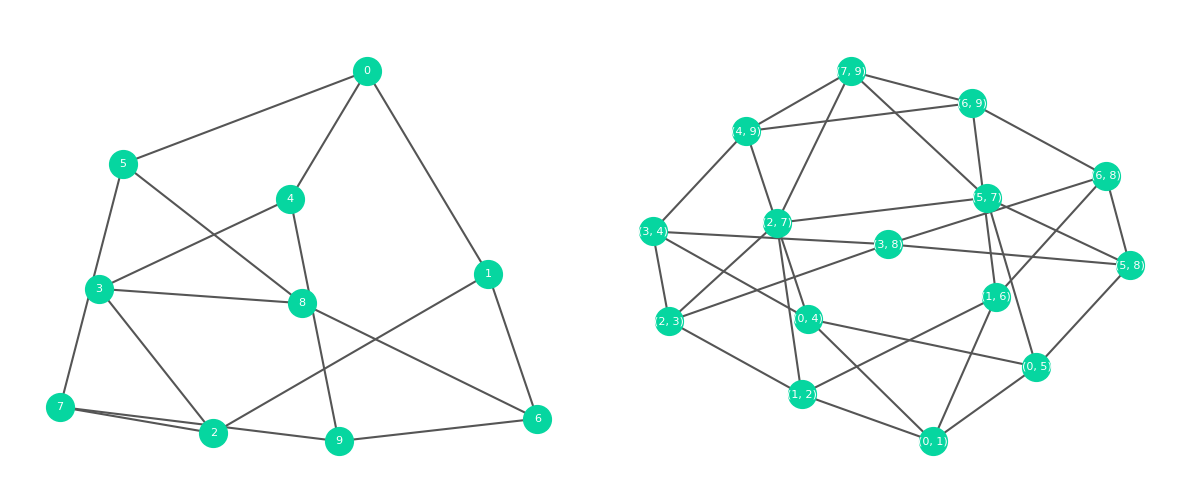

In [ ]:
# Comando NetworkX
# nx.line_graph(G)

base = nx.petersen_graph()
L = nx.line_graph(base)
print(f"Petersen: {base.number_of_nodes()} nodos, {base.number_of_edges()} aristas")
print(f"Line graph: {L.number_of_nodes()} nodos, {L.number_of_edges()} aristas")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor("#0f1419")
for ax, G_draw, title in zip(
    axes, [base, L], ["Petersen (original)", "Line Graph de Petersen"], strict=False
):
    ax.set_facecolor("#0f1419")
    nx.draw(
        G_draw,
        pos=nx.spring_layout(G_draw, seed=42),
        ax=ax,
        node_color="#06d6a0",
        node_size=400,
        edge_color="#555",
        width=1.5,
        with_labels=True,
        font_color="white",
        font_size=8,
    )
    ax.set_title(title, color="white", fontsize=12)
plt.tight_layout()
plt.show()

---
# 8️⃣ Resumen Comparativo

In [ ]:
import pandas as pd

catalog = [
    # Clásicos
    ("complete_graph(8)", nx.complete_graph(8)),
    ("complete_bipartite_graph(4,3)", nx.complete_bipartite_graph(4, 3)),
    ("path_graph(10)", nx.path_graph(10)),
    ("cycle_graph(10)", nx.cycle_graph(10)),
    ("star_graph(9)", nx.star_graph(9)),
    ("wheel_graph(10)", nx.wheel_graph(10)),
    # Árboles
    ("random_tree(15)", nx.random_labeled_tree(15, seed=42)),
    ("balanced_tree(3,3)", nx.balanced_tree(3, 3)),
    # Lattices
    ("grid_2d_graph(5,5)", nx.convert_node_labels_to_integers(nx.grid_2d_graph(5, 5))),
    ("hexagonal_lattice(4,4)", nx.hexagonal_lattice_graph(4, 4)),
    ("triangular_lattice(4,4)", nx.triangular_lattice_graph(4, 4)),
    # Aleatorios
    ("erdos_renyi(20,0.2)", nx.erdos_renyi_graph(20, 0.2, seed=42)),
    ("barabasi_albert(30,2)", nx.barabasi_albert_graph(30, 2, seed=42)),
    ("watts_strogatz(20,4,0.3)", nx.watts_strogatz_graph(20, 4, 0.3, seed=42)),
    ("random_regular(3,16)", nx.random_regular_graph(3, 16, seed=42)),
    # Famosos
    ("petersen_graph()", nx.petersen_graph()),
    ("dodecahedral_graph()", nx.dodecahedral_graph()),
    ("hypercube_graph(4)", nx.hypercube_graph(4)),
]

rows = []
for name, _g in catalog:
    degs = [d for _, d in _g.degree()]
    rows.append(
        {
            "Grafo": name,
            "Nodos": _g.number_of_nodes(),
            "Aristas": _g.number_of_edges(),
            "Grado min": min(degs),
            "Grado max": max(degs),
            "Grado medio": round(sum(degs) / len(degs), 2),
            "Conexo": "✅" if nx.is_connected(_g) else "❌",
            "Bipartito": "✅" if nx.is_bipartite(_g) else "❌",
        }
    )

df = pd.DataFrame(rows)
print(df.to_string(index=False))

                        Grafo  Nodos  Aristas  Grado min  Grado max  Grado medio Conexo Bipartito
            complete_graph(8)      8       28          7          7         7.00      ✅         ❌
complete_bipartite_graph(4,3)      7       12          3          4         3.43      ✅         ✅
               path_graph(10)     10        9          1          2         1.80      ✅         ✅
              cycle_graph(10)     10       10          2          2         2.00      ✅         ✅
                star_graph(9)     10        9          1          9         1.80      ✅         ✅
              wheel_graph(10)     10       18          3          9         3.60      ✅         ❌
              random_tree(15)     15       14          1          4         1.87      ✅         ✅
           balanced_tree(3,3)     40       39          1          4         1.95      ✅         ✅
           grid_2d_graph(5,5)     25       40          2          4         3.20      ✅         ✅
       hexagonal_lat

---
## 📚 Recursos

- [Documentación oficial NetworkX](https://networkx.org/documentation/stable/)
- [Generadores de grafos](https://networkx.org/documentation/stable/reference/generators.html)
- [Grafos clásicos](https://networkx.org/documentation/stable/reference/generators.html#classic)
